En un forward la leaky neuron integra en el tiempo (time steps). A mi me gustaría visualizar el potencial de membrana en el tiempo.

In [ ]:
import torch.nn as nn
import torch
import snntorch as snn
class LeakyNeuronTest(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.neuron = snn.Leaky()

    def forward(self, input_current):


        return input_current

In [33]:
import random
random.seed(0)
torch.use_deterministic_algorithms(True)
torch.manual_seed(1234)
import numpy as np
np.random.seed(0)

In [159]:
n = 2
channels = 200
test_input_current = torch.rand((n,channels))

In [160]:
class SpikeViz:
    def __init__(self):
        self.neuron_model_1 = snn.Leaky(beta = 0.999,
                                      threshold=0.1)
        self.neuron_model_2 = snn.Leaky(beta = 0.1,
                                      threshold=0.1)
        self.linear = nn.Linear(channels, channels)
        self.membrane_1_save = torch.empty((n,channels))
        self.membrane_2_save = torch.empty((n,channels))


    def __call__(self, current:list):
        membrane_potential_1 = self.neuron_model_1.init_leaky()
        membrane_potential_2 = self.neuron_model_2.init_leaky()

        spikes_1, membrane_potential_1 = self.neuron_model_1(current,membrane_potential_1 )
        new_current = self.linear(spikes_1)
        spikes_2, membrane_potential_2 = self.neuron_model_2(new_current, membrane_potential_2)
        return spikes_1, membrane_potential_1,spikes_2, membrane_potential_2
    

    

In [161]:
test = SpikeViz()

<Axes: >

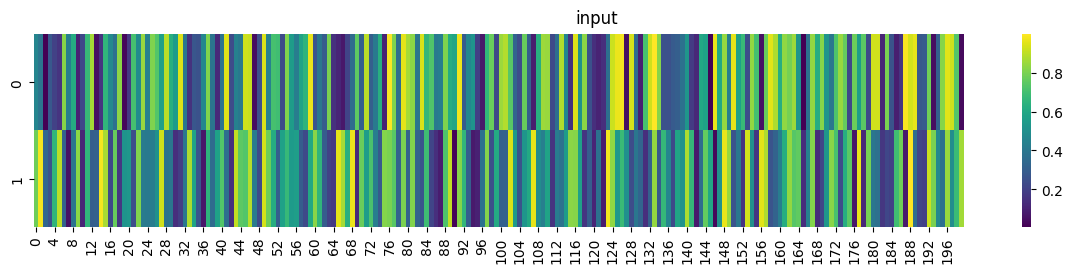

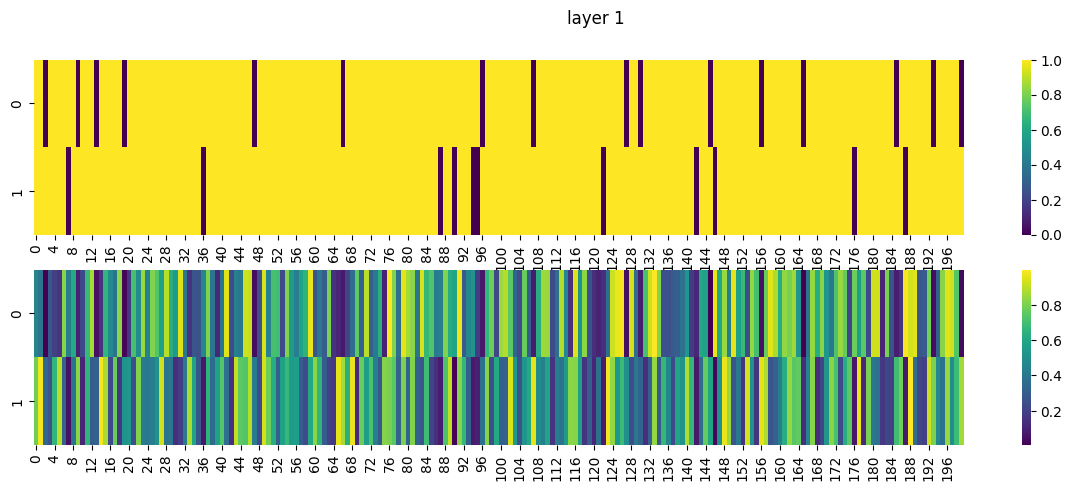

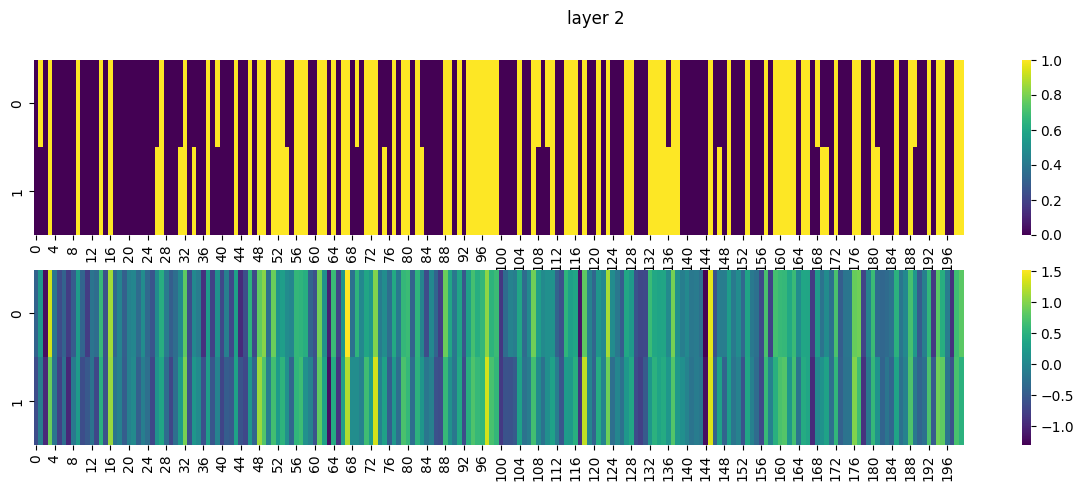

In [166]:

import seaborn as sns
output = test(test_input_current)
spikes1, mem1,spikes2, mem2 = (i.detach().numpy() for i in output)
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (15,2.5))
sns.heatmap(test_input_current,cmap = 'viridis',ax = fig.add_subplot(111, ))
fig.suptitle('input')

fig = plt.figure(figsize = (15,5))
sns.heatmap(spikes1,cmap = 'viridis',ax = fig.add_subplot(211, ))
sns.heatmap(mem1,cmap = 'viridis',ax = fig.add_subplot(212, ))
fig.suptitle('layer 1')

fig = plt.figure(figsize = (15,5))
fig.suptitle('layer 2')
sns.heatmap(spikes2,cmap = 'viridis',ax = fig.add_subplot(211, ))
sns.heatmap(mem2,cmap = 'viridis',ax = fig.add_subplot(212, ))

In [3]:
from spikemodel import ANGEL
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from ReportPretraining import QuickLoader
import torch
ql = QuickLoader(batch_size=128)

validation_dataloader = ql.validation
model = ANGEL(200) # initialize the model to the new class.
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
device = 'cuda:2'
model.to(device = device)
with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predicted = []
    all_probs = []
    for data in tqdm(validation_dataloader):
        #print(data.keys())
        inputs, labels =data['data'][:,:,0].float().to(device = device), data['labels'].long().to(device = device)  # Float
        outputs = model(inputs)
        predicted = torch.argmax(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())
        softmax = torch.nn.Softmax(dim=1)
        probabilities = softmax(outputs)[:, 1]  # Assuming 1 represents the positive class
        all_probs.extend(probabilities.cpu().numpy())
    avg_val_loss = test_loss/ len(validation_dataloader)
print(classification_report(all_labels, all_predicted, zero_division = 1, digits = 4))
model.to(device =  'cpu')

LC
using sampler
LC
LC


/tmp/ipykernel_2569915/3533644657.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


RuntimeError: Error(s) in loading state_dict for ANGEL:
	size mismatch for ln_out.weight: copying a param with shape torch.Size([400]) from checkpoint, the shape in current model is torch.Size([40000]).
	size mismatch for ln_out.bias: copying a param with shape torch.Size([400]) from checkpoint, the shape in current model is torch.Size([40000]).
	size mismatch for classifier.weight: copying a param with shape torch.Size([22, 400]) from checkpoint, the shape in current model is torch.Size([22, 40000]).